In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [4]:
data_dir = Path('../../data')
results_dir = Path('../../results')

ts = pd.read_csv(data_dir / 'imdb_ts.csv', index_col=0)
additional_features = pd.read_csv(results_dir / 'ts_additional_feats.csv', index_col=0)

In [5]:
ts.isna().values.any()

np.False_

In [6]:
ts = pd.merge(additional_features, ts, left_index=True, right_index=True)

No missing values in the entire dataframe.

We reorder the columns to make easier to inspect the dataframe.

In [7]:
cols = list(ts.columns[:6]) + list(ts.columns[-3:])
ts = ts[cols + [col for col in ts.columns if col not in cols]]

## Train test split

It would be nice if this time we could avoid data leakage.

In [8]:
train, test = train_test_split(ts, shuffle=True, random_state=42)

In [9]:
print("Training set:", train.shape)
print("Test set:", test.shape)

Training set: (850, 109)
Test set: (284, 109)


## Data exploration

In [10]:
train.head()

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,0,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt10855768,Missing,2023,111,68822,"US,RU",True,7.1,"['Drama', 'Mystery', 'Thriller']",High,3433703.0,...,180769.0,125336.0,86468.0,34939.0,41054.0,46551.0,39476.0,32835.0,24195.0,15942.0
tt3766354,The Equalizer 2,2018,121,218592,US,True,6.7,"['Action', 'Crime', 'Thriller']",Medium High,13375850.0,...,561537.0,560423.0,476123.0,386849.0,262398.0,145408.0,127290.0,108184.0,97706.0,85139.0
tt6791096,I Feel Pretty,2018,110,59184,"CN,US",True,5.7,"['Comedy', 'Romance']",Medium,6199651.0,...,105024.0,79110.0,57297.0,37058.0,44995.0,52408.0,45573.0,37329.0,32947.0,28392.0
tt1821549,Nebraska,2013,115,126617,US,True,7.7,['Drama'],High,35536.0,...,251542.0,207354.0,177589.0,146206.0,169318.0,200356.0,211349.0,220125.0,163567.0,106825.0
tt7144666,The Black Phone,2021,103,230716,US,True,6.9,"['Horror', 'Mystery', 'Thriller']",Medium High,10241355.0,...,523746.0,448800.0,317950.0,218585.0,223136.0,227210.0,209270.0,187610.0,161602.0,141360.0


In [11]:
train.iloc[:, :9].info()

<class 'pandas.core.frame.DataFrame'>
Index: 850 entries, tt10855768 to tt9620292
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                850 non-null    object 
 1   startYear            850 non-null    int64  
 2   runtimeMinutes       850 non-null    int64  
 3   numVotes             850 non-null    int64  
 4   countryOfOrigin      850 non-null    object 
 5   awardsOrNominations  846 non-null    object 
 6   rating               850 non-null    float64
 7   genre                850 non-null    object 
 8   rating_category      850 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 66.4+ KB


In [12]:
from ast import literal_eval

In [13]:
train['genre'] = train['genre'].apply(literal_eval)
train['countryOfOrigin'] = train['countryOfOrigin'].str.split(',')

### Distribution of numeric features

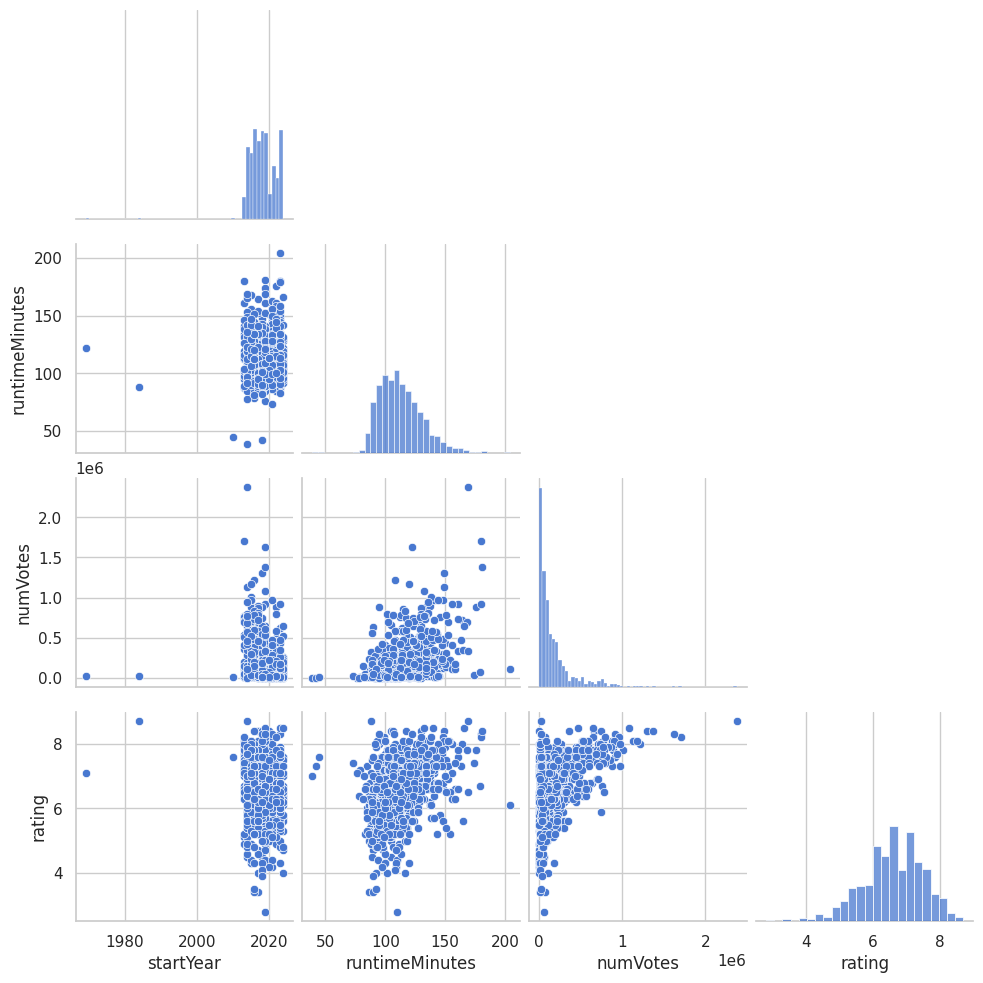

In [14]:
sns.pairplot(train, vars=['startYear', 'runtimeMinutes', 'numVotes', 'rating'], corner=True)

All of the records have normal runtimes for movies, except for 3 documentaries with runtime $\leq$ 45 minutes

In [15]:
train[train['runtimeMinutes'] < 50]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,0,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt3231010,Island of Lemurs: Madagascar,2014,39,1050,"[CA, US, MG]",True,7.0,"[Documentary, Short, Adventure]",Medium High,57326.0,...,43594.0,35506.0,34024.0,32765.0,28718.0,26583.0,29048.0,31629.0,38254.0,44658.0
tt7860270,Pandas,2018,42,776,[US],True,7.3,"[Documentary, Short]",High,59728.0,...,44159.0,38325.0,38062.0,37858.0,30437.0,22984.0,21404.0,20198.0,22996.0,25430.0
tt1433813,Hubble,2010,45,4615,"[US, CA]",True,7.6,[Documentary],High,131025.0,...,120846.0,101100.0,78704.0,56433.0,60007.0,63236.0,67514.0,71599.0,77404.0,81896.0


All records except 2 are fairly recent (released in 2010 or later).

Ignoring outliers, the distribution of movies for release date is uniform, except for the already observed dip in 2020.

<Axes: xlabel='startYear'>

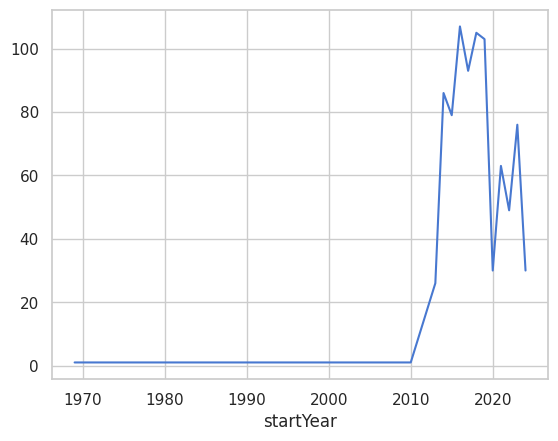

In [16]:
train.groupby('startYear')['title'].count().plot()

In [17]:
train[train['startYear'] < 2010]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,0,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt0088178,Stop Making Sense,1984,88,22937,[US],True,8.7,"[Documentary, Music]",High,332925.0,...,16273.0,14396.0,10518.0,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0
tt0064816,The Swimming Pool,1969,122,15308,"[FR, IT]",False,7.1,"[Crime, Drama, Romance]",High,1923.0,...,1995.0,1972.0,1251.0,637.0,734.0,857.0,785.0,724.0,713.0,699.0


Distribution of `numVotes` has a right skew.

In [46]:
train.numVotes.describe()

count    8.500000e+02
mean     1.803665e+05
std      2.410378e+05
min      8.500000e+01
25%      3.428200e+04
50%      9.672950e+04
75%      2.190652e+05
max      2.374947e+06
Name: numVotes, dtype: float64

In [18]:
train.sort_values('numVotes', ascending=False)

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,0,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt0816692,Interstellar,2014,169,2374947,"[US, GB, CA]",True,8.7,"[Adventure, Drama, Sci-Fi]",High,1350209.0,...,593663.0,720577.0,896340.0,1070807.0,991763.0,910905.0,786939.0,660732.0,710859.0,763250.0
tt0993846,The Wolf of Wall Street,2013,180,1703709,[US],True,8.2,"[Biography, Comedy, Crime]",High,9150379.0,...,516835.0,636727.0,921125.0,1212685.0,959817.0,733352.0,485552.0,215064.0,230368.0,244186.0
tt7286456,Joker,2019,122,1625673,"[US, CA, AU]",True,8.3,"[Crime, Drama, Thriller]",High,39350693.0,...,1908740.0,1371816.0,943600.0,426673.0,513630.0,609986.0,533751.0,443301.0,383414.0,328871.0
tt4154796,Avengers: Endgame,2019,181,1374452,[US],NaN,8.4,"[Action, Adventure, Sci-Fi]",High,157461641.0,...,1829579.0,1583859.0,1057981.0,598373.0,700030.0,790276.0,686876.0,601476.0,570854.0,547331.0
tt4154756,Avengers: Infinity War,2018,149,1302471,"[US, NO]",True,8.4,"[Action, Adventure, Sci-Fi]",High,106334939.0,...,2644515.0,2403780.0,1719860.0,922933.0,1054992.0,1182541.0,1051254.0,895177.0,820151.0,766901.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tt5738280,Dutch,2021,109,648,[US],False,4.2,[Action],Medium Low,37909.0,...,1981.0,2259.0,1476.0,861.0,897.0,933.0,911.0,889.0,1022.0,1181.0
tt13820428,Witnesses,2021,110,465,[US],False,4.4,"[Action, Adventure, Drama]",Medium Low,72670.0,...,4138.0,674.0,3947.0,7035.0,5704.0,4314.0,3286.0,2671.0,2656.0,2639.0
tt13502506,L'Arracheuse de temps,2021,105,325,[CA],True,6.2,[Fantasy],Medium,56934.0,...,1777.0,2471.0,1932.0,1402.0,1333.0,1247.0,885.0,655.0,1052.0,1442.0


### Distribution of categorical features

In [19]:
train['rating_category'] = pd.Categorical(train['rating_category'],
               categories=['Low', 'Medium Low', 'Medium', 'Medium High', 'High'],
               ordered=True)

<Axes: xlabel='rating_category', ylabel='count'>

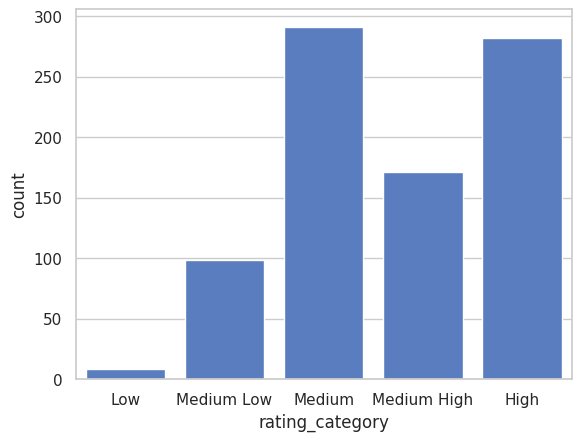

In [20]:
sns.countplot(train, x='rating_category')

Almost all titles received awards or nominations.

<Axes: xlabel='awardsOrNominations'>

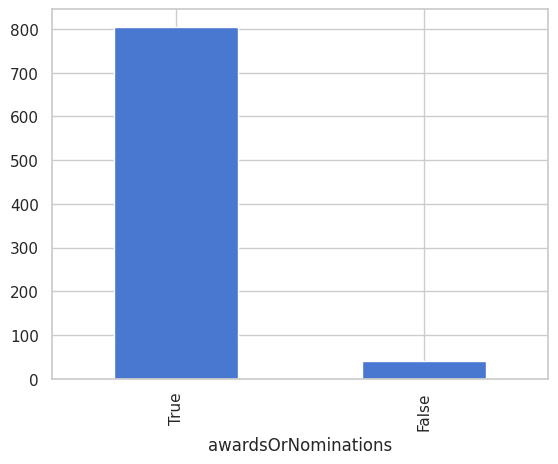

In [24]:
train['awardsOrNominations'].value_counts().plot.bar()

<Axes: ylabel='genre'>

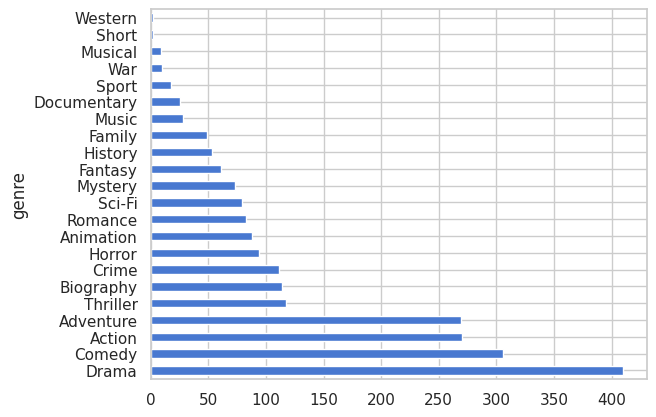

In [26]:
genres_train = train.explode('genre')
genres_train['genre'].value_counts().plot.barh()

<Axes: ylabel='countryOfOrigin'>

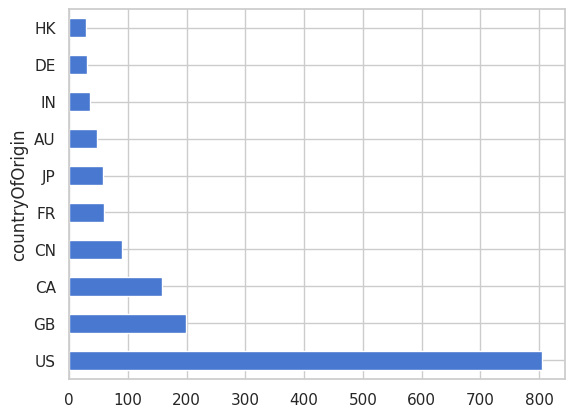

In [31]:
country_train = train.explode('countryOfOrigin')
country_counts = country_train['countryOfOrigin'].value_counts()
country_counts.to_frame().sort_values('count', ascending=False).head(10).plot.barh(legend=False)

In [44]:
train[train['countryOfOrigin'].apply(lambda x: 'US' not in x)].shape[0]

46

Only a small proportion of these movies was not produced in the United States.